## Linear Regression  with insurance data

In [1]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib as mpl
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 100
font = {"family": "sans-serif", "size": 12}

mpl.rc("font", **font)

from IPython.display import Image

You are provided a dataset of insurance where we have the details of customers. Your task is to build a **linear regression model** for predicting the insuarance charges

In [2]:
df = pd.read_csv("insurance_data.csv")
df.head(10)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.543130,17.0,715428.0,4.720921e+06,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.674370,7.0,699157.0,4.329832e+06,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.627590,19.0,702341.0,6.884861e+06,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.393320,11.0,700250.0,4.274774e+06,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.859410,16.0,711584.0,3.787294e+06,0.0,23012320.01,southeast,1137.0110
5,18.0,male,34.43,0.0,no,26488.339120,20.0,717162.0,3.696161e+06,0.0,NaN,southeast,1137.4697
6,18.0,male,37.29,0.0,no,33217.365480,13.0,699159.0,8.765292e+05,0.0,69060665.92,southeast,1141.4451
7,18.0,male,41.14,0.0,no,46770.585330,12.0,706423.0,4.486741e+06,0.0,97193784.44,southeast,1146.7966
8,18.0,male,43.01,0.0,no,9715.650411,17.0,NaN,9.216440e+06,0.0,58881971.93,southeast,1149.3959
9,18.0,male,53.13,0.0,no,17046.585150,19.0,704425.0,1.458972e+06,0.0,94261821.45,southeast,1163.4627


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [4]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [5]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [6]:
print('Total null values',df.isnull().sum().sum())

df.isnull().sum().sum()/df.shape[1]

Total null values 52


np.float64(4.0)

In [7]:
null_cols = df.isnull().columns
df_nulls = df[null_cols]
df_nulls.describe()


,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [8]:
## Obejct data type column -> fill the null values --> Mode
## Numeric data type column -> fill the null values --> Mean

for x in df.columns:
    if df[x].dtype == 'object':
        df[x].fillna(df[x].mode()[0], inplace=True)

    else:
        df[x].fillna(df[x].mean(), inplace=True)



/tmp/ipykernel_2400105/2146053108.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[x].fillna(df[x].mean(), inplace=True)
/tmp/ipykernel_2400105/2146053108.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

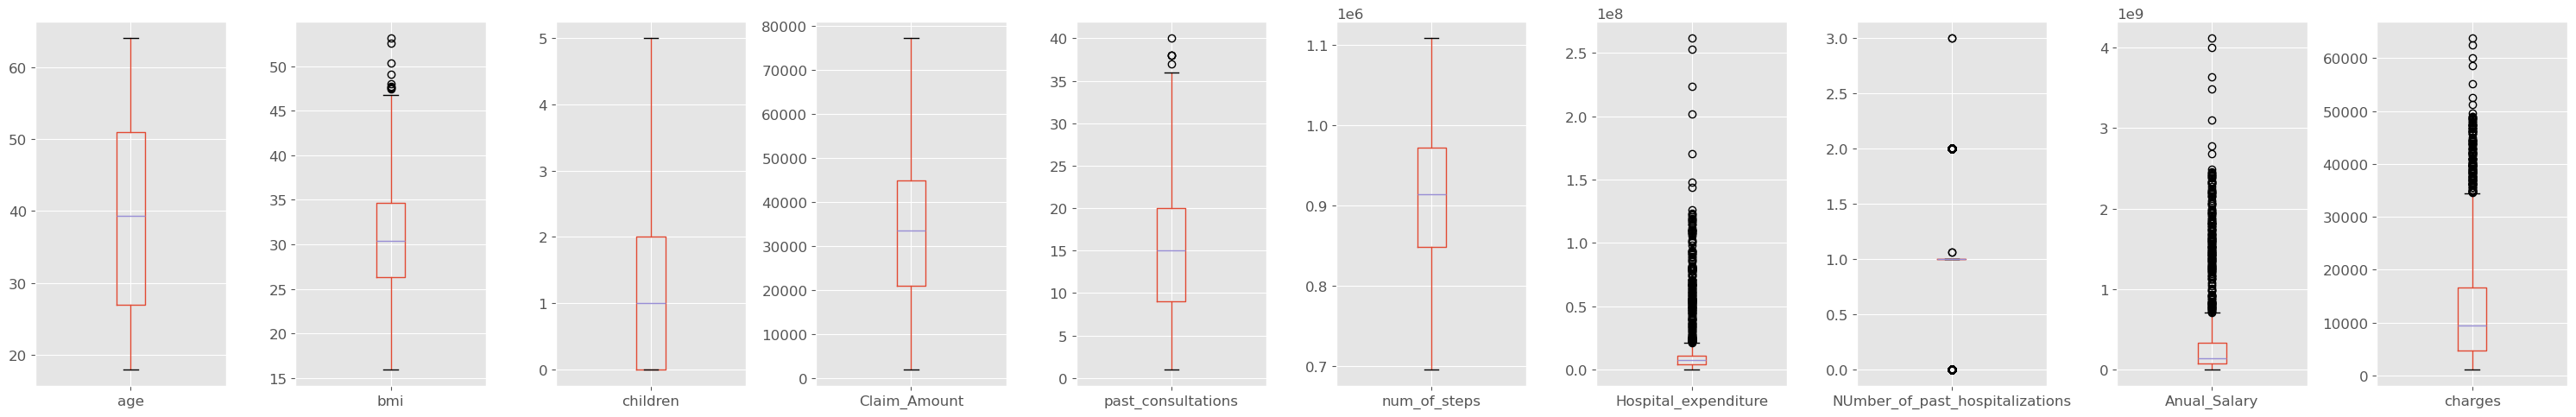

In [9]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(1, len(numeric_columns), figsize=(30, 5))
for ax, col in zip(axes, numeric_columns):
    df.boxplot(column=col, ax=ax) 

plt.tight_layout()
plt.show()

In [10]:
len(numeric_columns)

10

## Feature selection

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
check_vifs = [i for i in numeric_columns if i != 'charges']

vif = pd.DataFrame()
vif["Features"] = check_vifs   # no need to go through df[check_vifs].columns

vif_list = []
for i in range(len(check_vifs)):
    vif_value = variance_inflation_factor(df[check_vifs].values, i)
    vif_list.append(vif_value)

vif["VIF"] = vif_list
print(vif)

                          Features        VIF
0                              age   1.719734
1                              bmi   1.090564
2                         children   1.077415
3                     Claim_Amount   1.231880
4               past_consultations   1.631107
5                     num_of_steps   6.503816
6             Hospital_expenditure  16.272701
7  NUmber_of_past_hospitalizations   3.988100
8                     Anual_Salary  23.762922


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def compute_vif(df, exclude_columns=None):
 
    if exclude_columns is None:
        exclude_columns = []

    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    check_vifs = [col for col in numeric_columns if col not in exclude_columns]

    # Drop rows with NaNs to avoid errors/unreliable VIF values
    df_check = df[check_vifs].dropna()

    vif = pd.DataFrame()
    vif["Features"] = check_vifs
    vif["VIF"] = [
        variance_inflation_factor(df_check.values, i)
        for i in range(len(check_vifs))
    ]

    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)



In [13]:
vif_result = compute_vif(df, exclude_columns=['charges'])
print(vif_result)

#After inspecting, drop the worst offender(s) and recompute
vif_result2 = compute_vif(df, exclude_columns=['charges', 'Anual_Salary'])
print(vif_result2)


vif_result3 = compute_vif(df, exclude_columns=['charges', 'Anual_Salary', 'num_of_steps'])
print(vif_result3)

                          Features        VIF
0                     Anual_Salary  23.762922
1             Hospital_expenditure  16.272701
2                     num_of_steps   6.503816
3  NUmber_of_past_hospitalizations   3.988100
4                              age   1.719734
5               past_consultations   1.631107
6                     Claim_Amount   1.231880
7                              bmi   1.090564
8                         children   1.077415
                          Features       VIF
0                     num_of_steps  5.056308
1  NUmber_of_past_hospitalizations  3.937098
2             Hospital_expenditure  2.240459
3               past_consultations  1.614786
4                              age  1.526450
5                     Claim_Amount  1.230532
6                              bmi  1.087982
7                         children  1.060960
                          Features       VIF
0  NUmber_of_past_hospitalizations  2.267044
1             Hospital_expenditure  2.174077


In [14]:
df = df.drop(['Anual_Salary', 'num_of_steps'],axis = 1)

In [15]:
df.shape

(1338, 11)

In [16]:
# until VIF < 5
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   Hospital_expenditure             1338 non-null   float64
 8   NUmber_of_past_hospitalizations  1338 non-null   float64
 9   region                           1338 non-null   object 
 10  charges                          1338 non-null   float64
dtypes: float64(8), object(3)
memory usage: 115.1+ KB


## Label encoding 

In [17]:
df['region'].unique()

array(['southeast', 'southwest', 'northwest', 'northeast'], dtype=object)

In [18]:
object_columns = df.select_dtypes(include=['object']).columns.to_numpy()
print(object_columns)

['sex' 'smoker' 'region']


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

to_be_encoded = [i for i in object_columns if i != 'region']
print(to_be_encoded)

for col in to_be_encoded:
    df[col] = le.fit_transform(df[col])
df.info()

['sex', 'smoker']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   int64  
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   int64  
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   Hospital_expenditure             1338 non-null   float64
 8   NUmber_of_past_hospitalizations  1338 non-null   float64
 9   region                           1338 non-null   object 
 10  charges                          1338 non-null   float64
dtypes: float64(8), int64(2), object(1)
memory usage: 115.1+ KB


## One hot encoding

In [20]:
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'charges', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

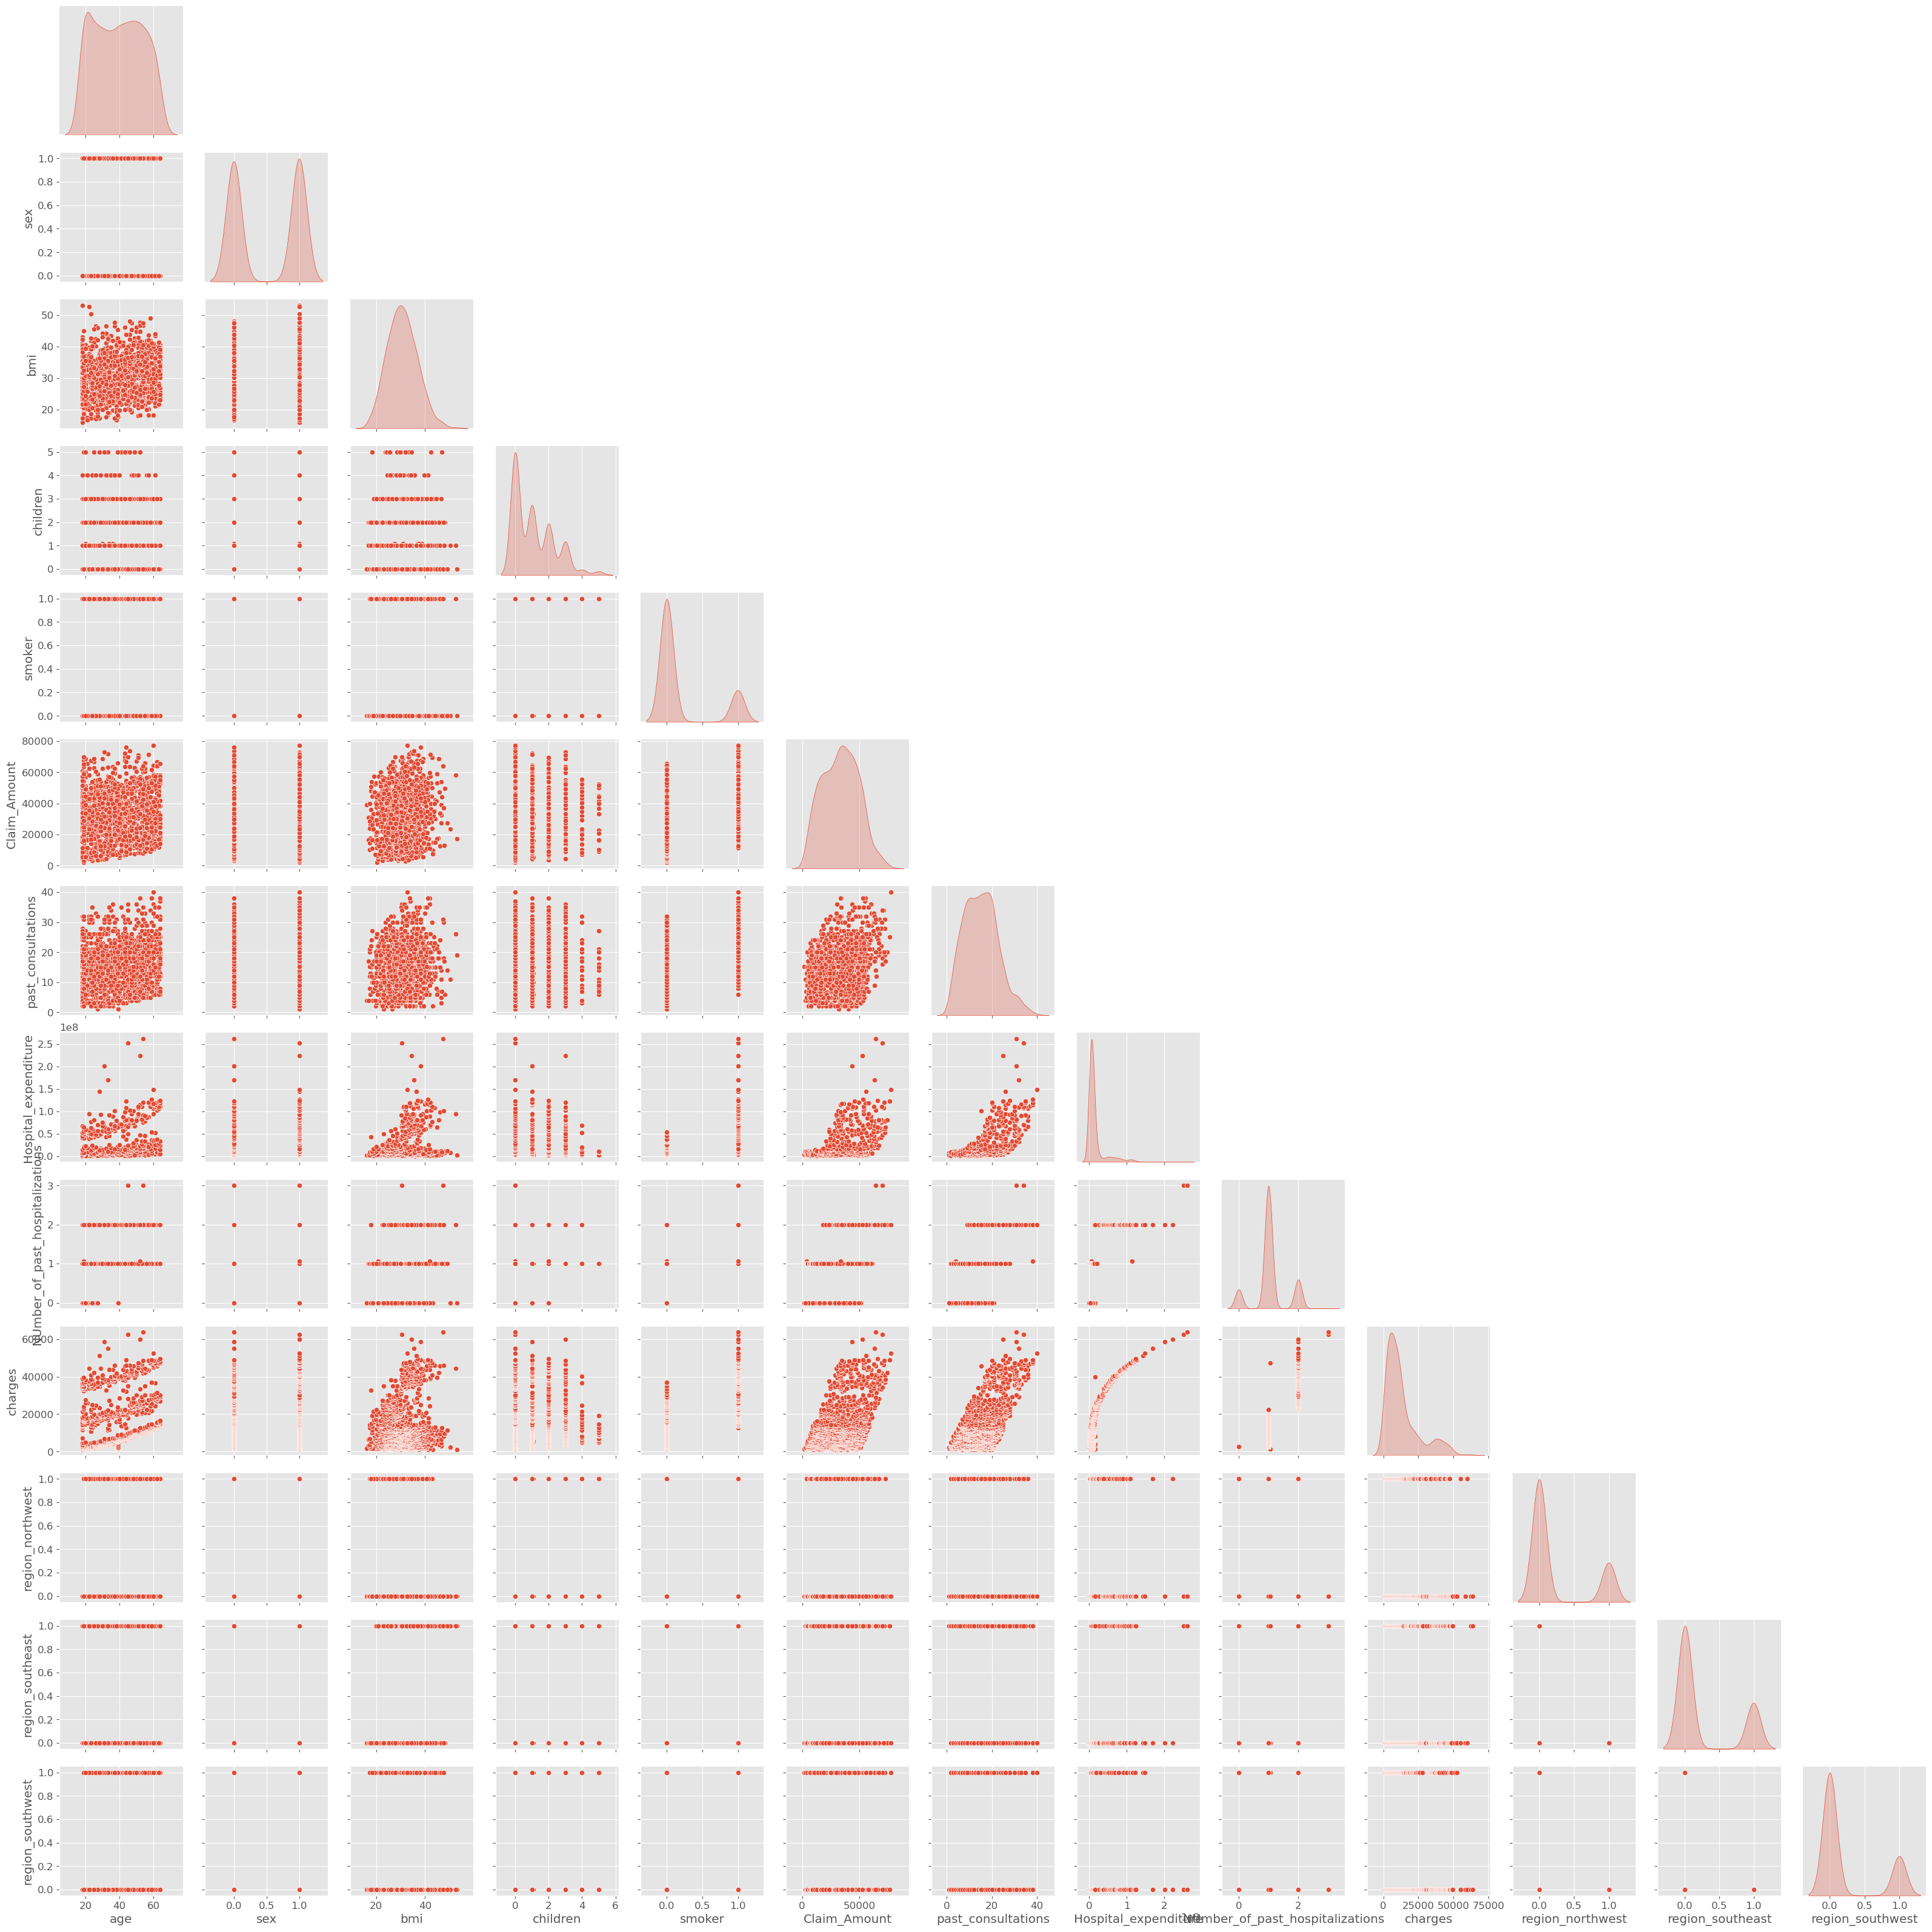

In [22]:
sns.pairplot(df,corner=True,diag_kind='kde')


In [23]:
y = df['charges']
X = df.drop('charges', axis= 1) # axis = 1 for column axis 

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1070, 12)
X_test : (268, 12)
y_train: (1070,)
y_test : (268,)


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression().fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred

array([ 1.18075384e+04,  7.89046889e+03,  9.71900146e+03,  1.86130691e+04,
        6.12456269e+03,  1.10775513e+04, -1.86313276e+03,  3.72571203e+04,
        3.34136900e+04,  4.96473216e+04,  8.33459927e+03,  1.02845839e+04,
        3.67292412e+04,  8.28056320e+03,  1.10846148e+04,  1.14462396e+04,
        9.66855926e+03, -3.50963224e+02,  2.41000342e+04,  1.04775675e+04,
        1.39638263e+04,  8.52432517e+03,  8.91578306e+03,  9.70797247e+03,
        2.07779000e+04,  8.26136491e+03,  4.10491331e+04,  8.06424970e+03,
        1.05825268e+03,  1.03056268e+04, -4.62079207e+02,  1.84713181e+04,
        8.98084082e+03,  9.61115796e+02,  1.83762941e+04,  1.82736318e+04,
        1.43948265e+04, -7.95219451e+02,  1.15924331e+04,  3.89517503e+04,
        1.13717792e+04, -1.78802659e+03,  1.02925284e+04,  2.92137278e+02,
        5.71247337e+03,  1.69013564e+04,  7.58224990e+03,  4.86211154e+04,
        2.87472975e+04,  1.10845930e+04,  3.25489457e+04,  3.25985240e+04,
        1.41867604e+03,  

In [26]:

print(f"Coefficients = {lr.coef_}, {len(lr.coef_)}")
print(f"Intercept = {lr.intercept_}")

print(f"Training set r2 score = {lr.score(X_train, y_train):.2f}")
print(f"Test set r2 score = {lr.score(X_test, y_test):.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
pass

Coefficients = [ 1.15958528e+02  2.72772232e+01  6.30520441e+01 -5.92662721e+01
  9.40165099e+03  2.90872525e-02  1.31735241e+02  1.85267533e-04
  5.80704657e+03 -4.38135935e+02 -4.96137835e+02 -5.30372622e+02], 12
Intercept = -6820.978492981887
Training set r2 score = 0.93
Test set r2 score = 0.93
Mean Squared Error: 10724443.30
